# E-Commerce Sales — Exploratory Data Analysis

## Project Overview

This project performs an end-to-end exploratory data analysis (EDA) on an e-commerce sales dataset.

The analysis focuses on sales, profit, discounts, product categories, regions, and time-based trends. The goal is to understand the dataset, identify data-quality issues, explore relationships between variables, and extract meaningful business insights.

### Business Questions
- Which product categories generate the most profit?
- How does discounting relate to profitability?
- Which regions generate the most sales and profit?
- How do sales change over time?
- Is there a relationship between sales and profit?
- What characterizes loss-making orders?


In [57]:
import pandas as pd
df = pd.read_csv('project_2_ecommerce_sales.csv')

## 1. Dataset Dimensions

First, we inspect the number of observations and variables in the dataset.

In [58]:
df.shape

(1208, 14)

## 2. Dataset Structure

Next, we inspect the column names, data types, and non-null counts to understand the structure of the data.

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1208 entries, 0 to 1207
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1208 non-null   object 
 1   Order_Date     1208 non-null   object 
 2   Ship_Date      1208 non-null   object 
 3   Customer       1196 non-null   object 
 4   Region         1198 non-null   object 
 5   Category       1208 non-null   object 
 6   Product        1208 non-null   object 
 7   Quantity       1208 non-null   int64  
 8   Unit_Price     1208 non-null   float64
 9   Discount       1201 non-null   float64
 10  Sales          1208 non-null   float64
 11  Cost           1208 non-null   float64
 12  Profit         1208 non-null   float64
 13  Shipping_Mode  1202 non-null   object 
dtypes: float64(5), int64(1), object(8)
memory usage: 132.3+ KB


## 3. Descriptive Statistics

`describe()` provides summary statistics for the numerical variables, including count, mean, standard deviation, minimum, and maximum values.

In [60]:
df.describe()

,Quantity,Unit_Price,Discount,Sales,Cost,Profit
count,1208.000000,1208.000000,1201.000000,1208.000000,1208.000000,1208.000000
mean,3.993377,162.225993,0.094796,599.348469,502.244089,97.104379
std,2.003300,217.071496,0.077648,943.258434,818.342946,160.036143
min,1.000000,10.000000,0.000000,8.000000,5.800000,-448.000000
25%,2.000000,18.000000,0.050000,60.900000,41.760000,16.100000
50%,4.000000,70.000000,0.100000,176.000000,130.200000,38.250000
75%,6.000000,220.000000,0.150000,720.000000,624.000000,107.800000
max,7.000000,800.000000,0.300000,5600.000000,4368.000000,1232.000000


## 4. Data Types

Understanding data types is important before analysis because numerical, categorical, and date variables require different analytical approaches.

In [61]:
df.dtypes

,0
Order_ID,object
Order_Date,object
Ship_Date,object
Customer,object
Region,object
Category,object
Product,object
Quantity,int64
Unit_Price,float64
Discount,float64


## 5. Preview of the Dataset

The first few rows provide a quick look at the structure and values contained in the dataset.

In [62]:
df.head()

,Order_ID,Order_Date,Ship_Date,Customer,Region,Category,Product,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Shipping_Mode
0,ORD10001,2024-06-04,2024-06-09,Customer_0188,North,Furniture,Filing Cabinet,6,150.0,0.05,855.0,648.0,207.0,Express
1,ORD10002,2024-08-05,2024-08-10,Customer_0086,South,Accessories,Phone Stand,3,20.0,0.10,54.0,37.2,16.8,Standard
2,ORD10003,2024-07-08,2024-07-15,Customer_0052,South,Office Supplies,File Folder,2,10.0,0.00,20.0,11.6,8.4,Standard
3,ORD10004,2025-02-20,2025-02-26,Customer_0111,Central,Office Supplies,Printer Paper,4,25.0,0.10,90.0,58.0,32.0,Express
4,ORD10005,2025-11-05,2025-11-08,Customer_0043,West,Electronics,Laptop,6,800.0,0.10,4320.0,3744.0,576.0,Standard


## 6. Missing-Value Check

We check each column for missing values before beginning deeper analysis.

In [63]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Ship_Date,0
Customer,12
Region,10
Category,0
Product,0
Quantity,0
Unit_Price,0
Discount,7


## 7. Duplicate Check

We check whether the dataset contains duplicate records.

In [64]:
df.duplicated().sum()


np.int64(8)

### Duplicate Records

The duplicated rows are displayed so that we can understand what needs to be removed during the cleaning stage.

In [65]:
df[df.duplicated(keep=False)].sort_values('Order_ID')

,Order_ID,Order_Date,Ship_Date,Customer,Region,Category,Product,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Shipping_Mode
141,ORD10142,2024-01-08,2024-01-14,Customer_0019,West,Electronics,Smartphone,4,600.0,0.10,2160.0,1872.00,288.00,Standard
1203,ORD10142,2024-01-08,2024-01-14,Customer_0019,West,Electronics,Smartphone,4,600.0,0.10,2160.0,1872.00,288.00,Standard
151,ORD10152,2025-06-10,2025-06-16,Customer_0155,West,Electronics,Headphones,7,120.0,0.00,840.0,655.20,184.80,Standard
1206,ORD10152,2025-06-10,2025-06-16,Customer_0155,West,Electronics,Headphones,7,120.0,0.00,840.0,655.20,184.80,Standard
457,ORD10458,2025-05-31,2025-06-02,Customer_0099,South,Furniture,Filing Cabinet,7,150.0,0.15,892.5,756.00,136.50,Same Day
1201,ORD10458,2025-05-31,2025-06-02,Customer_0099,South,Furniture,Filing Cabinet,7,150.0,0.15,892.5,756.00,136.50,Same Day
459,ORD10460,2024-01-20,2024-01-27,Customer_0075,North,Electronics,Smartphone,4,600.0,0.00,2400.0,1872.00,528.00,Standard
1200,ORD10460,2024-01-20,2024-01-27,Customer_0075,North,Electronics,Smartphone,4,600.0,0.00,2400.0,1872.00,528.00,Standard
668,ORD10669,2025-02-24,2025-03-02,Customer_0179,East,Electronics,Monitor,4,250.0,0.15,850.0,780.00,70.00,Express
1204,ORD10669,2025-02-24,2025-03-02,Customer_0179,East,Electronics,Monitor,4,250.0,0.15,850.0,780.00,70.00,Express


## 8. Unique Values

Counting unique values helps distinguish categorical variables and understand the variety of observations in each column.

In [66]:
df.nunique()

,0
Order_ID,1200
Order_Date,583
Ship_Date,583
Customer,292
Region,5
Category,4
Product,20
Quantity,7
Unit_Price,19
Discount,6


## 9. Region Distribution

We examine how frequently each region appears in the dataset.

In [67]:
df["Region"].value_counts(dropna=False)

,count
Region,
West,271
North,264
South,263
Central,202
East,198
NaN,10


## 10. Category Distribution

We examine the frequency of each product category.

In [68]:
df["Category"].value_counts(dropna=False)

,count
Category,
Electronics,381
Office Supplies,335
Accessories,255
Furniture,237


## 11. Product Distribution

We examine how frequently individual products appear.

In [69]:
df["Product"].value_counts(dropna=False)

,count
Product,
File Folder,86
Monitor,85
Smartphone,82
Headphones,75
Stapler,73
Keyboard,73
Phone Stand,67
Pen Set,67
Laptop,66


## 12. Shipping Mode Distribution

We examine the frequency of each shipping method.

In [70]:
df["Shipping_Mode"].value_counts(dropna=False)

,count
Shipping_Mode,
Standard,727
Express,350
Same Day,125
NaN,6


## 13. Numerical Variable Summary

Transposing `describe()` makes it easier to compare the summary statistics of each numerical variable.

In [71]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,1208.0,3.993377,2.003300,1.0,2.00,4.00,6.00,7.0
Unit_Price,1208.0,162.225993,217.071496,10.0,18.00,70.00,220.00,800.0
Discount,1201.0,0.094796,0.077648,0.0,0.05,0.10,0.15,0.3
Sales,1208.0,599.348469,943.258434,8.0,60.90,176.00,720.00,5600.0
Cost,1208.0,502.244089,818.342946,5.8,41.76,130.20,624.00,4368.0
Profit,1208.0,97.104379,160.036143,-448.0,16.10,38.25,107.80,1232.0


## 14. Loss-Making Orders

Before looking at profitability in detail, we identify how many orders have negative profit.

In [72]:
df[df["Profit"]<0].shape

(29, 14)

### Details of Loss-Making Orders

We inspect the characteristics of loss-making orders, including category, product, quantity, price, discount, sales, cost, and profit.

In [73]:
df[df["Profit"] < 0][
    ["Category", "Product", "Quantity", "Unit_Price",
     "Discount", "Sales", "Cost", "Profit"]
]

,Category,Product,Quantity,Unit_Price,Discount,Sales,Cost,Profit
56,Electronics,Headphones,6,120.0,0.3,504.0,561.6,-57.6
77,Electronics,Smartphone,2,600.0,0.3,840.0,936.0,-96.0
102,Furniture,Office Chair,4,220.0,0.3,616.0,633.6,-17.6
108,Electronics,Laptop,7,800.0,0.3,3920.0,4368.0,-448.0
111,Electronics,Smartphone,6,600.0,0.3,2520.0,2808.0,-288.0
152,Electronics,Monitor,5,250.0,0.3,875.0,975.0,-100.0
160,Furniture,Bookshelf,5,180.0,0.3,630.0,648.0,-18.0
328,Furniture,Desk,1,300.0,0.3,210.0,216.0,-6.0
356,Electronics,Keyboard,2,70.0,0.3,98.0,109.2,-11.2
404,Furniture,Bookshelf,4,180.0,0.3,504.0,518.4,-14.4


## 15. Discount vs. Average Profit

We compare average profit across discount levels to investigate whether higher discounts are associated with lower profitability.

In [74]:
df.groupby("Discount")["Profit"].mean()

,Profit
Discount,
0.00,164.168264
0.05,111.767385
0.10,96.167157
0.15,62.907047
0.20,28.874571
0.30,-51.819592


### Discount-Level Profit Summary

Mean, minimum, and count provide additional context for the profit distribution at each discount level.

In [75]:
df.groupby("Discount")["Profit"].agg(["mean", "min", "count"])

,mean,min,count
Discount,,,
0.00,164.168264,4.2,288
0.05,111.767385,3.7,218
0.10,96.167157,3.2,313
0.15,62.907047,2.7,193
0.20,28.874571,1.4,140
0.30,-51.819592,-448.0,49


### Profit Distribution by Discount

The box plot helps compare the median, spread, and potential outliers of profit at different discount levels.

**Insight:** Profit generally shifts downward as the discount level increases. The 30% discount group contains several loss-making observations.

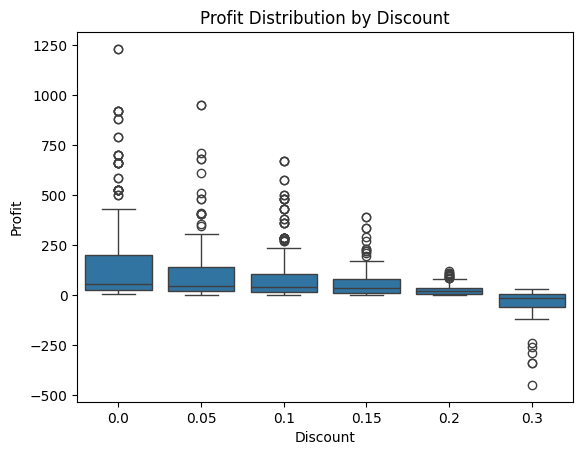

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Discount", y="Profit", data=df)
plt.title("Profit Distribution by Discount")
plt.show()

## 16. Profit by Category

We compare average, minimum, maximum, and number of orders across product categories.

In [77]:
df.groupby("Category")["Profit"].agg(["mean", "min", "max", "count"])

,mean,min,max,count
Category,,,,
Accessories,41.859922,0.96,199.5,255
Electronics,177.800787,-448.00,1232.0,381
Furniture,136.460338,-30.80,588.0,237
Office Supplies,19.536149,2.20,73.5,335


### Profit Distribution by Category

The box plot shows how profit is distributed within each category.

**Insight:** Electronics has both very high and very low profit observations, indicating substantial variability.

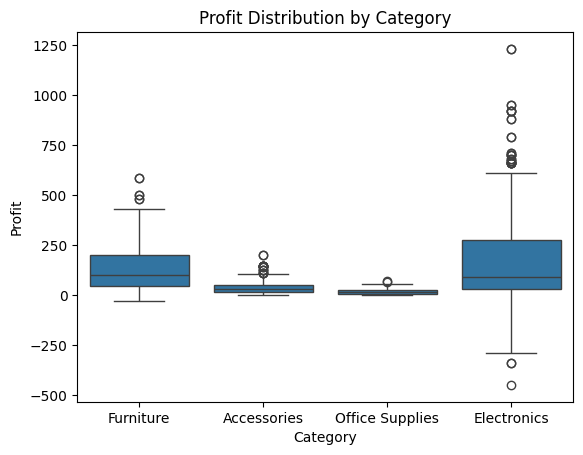

In [78]:
sns.boxplot(x="Category", y="Profit", data=df)
plt.title("Profit Distribution by Category")
plt.show()

### Profit Variability by Category

Standard deviation is used here as a measure of how widely profit values vary within each category.

In [79]:
df.groupby("Category")["Profit"].agg(["mean", "std"])

,mean,std
Category,,
Accessories,41.859922,36.965866
Electronics,177.800787,237.934597
Furniture,136.460338,119.211638
Office Supplies,19.536149,13.095767


### Mean, Median, and Variability

Comparing mean, median, standard deviation, minimum, and maximum gives a more complete picture than using average profit alone.

In [80]:
df.groupby("Category")["Profit"].agg(
    mean="mean",
    median="median",
    std="std",
    min="min",
    max="max"
).round(2)

,mean,median,std,min,max
Category,,,,,
Accessories,41.86,30.8,36.97,0.96,199.5
Electronics,177.80,90.0,237.93,-448.00,1232.0
Furniture,136.46,101.2,119.21,-30.80,588.0
Office Supplies,19.54,16.8,13.10,2.20,73.5


### Median Profit by Category

The median represents the middle profit value and helps describe the typical order without being as influenced by extreme observations.

In [81]:
df.groupby("Category")["Profit"].median().sort_values(ascending=False)

,Profit
Category,
Furniture,101.2
Electronics,90.0
Accessories,30.8
Office Supplies,16.8


## 17. Category-Level Business Metrics

We compare average sales, cost, profit, quantity, and discount across categories.

**Insight:** Electronics has much higher average sales and profit than the other categories, while average quantity and discount are relatively similar across categories.

In [82]:
df.groupby("Category")[["Sales", "Cost", "Profit", "Quantity", "Discount"]].mean().round(2)

,Sales,Cost,Profit,Quantity,Discount
Category,,,,,
Accessories,132.73,90.87,41.86,3.92,0.10
Electronics,1352.98,1175.18,177.80,4.13,0.10
Furniture,661.48,525.02,136.46,4.03,0.10
Office Supplies,53.46,33.92,19.54,3.86,0.09


### Profit Margin by Category

Profit margin is calculated as total profit divided by total sales.

**Insight:** Office Supplies has the highest profit margin, while Electronics has the lowest profit margin. Therefore, the category with the highest average profit is not necessarily the category with the highest profitability relative to sales.

In [83]:
df.groupby("Category").apply(
    lambda x: (x["Profit"].sum() / x["Sales"].sum()) * 100
).round(2)

/tmp/ipykernel_2058/870438110.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("Category").apply(


,0
Category,
Accessories,31.54
Electronics,13.14
Furniture,20.63
Office Supplies,36.54


## 18. Monthly Sales Trend

We convert `Order_Date` to a datetime and aggregate sales by month to examine changes over time.

**Insight:** Monthly sales fluctuate considerably. June 2024 records the highest monthly sales in this dataset, but there is no consistent overall upward or downward trend across the two-year period.

<Axes: xlabel='Order_Date'>

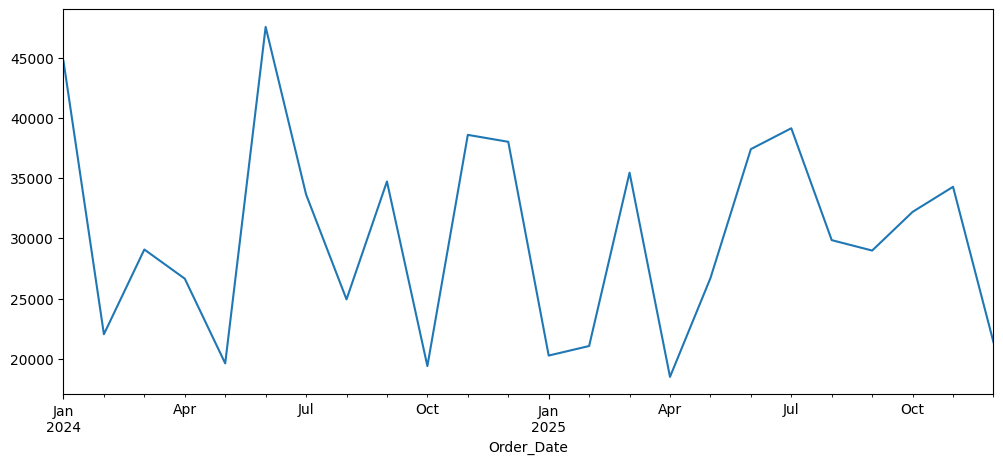

In [84]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df.groupby(df["Order_Date"].dt.to_period("M"))["Sales"].sum().plot(figsize=(12,5))

## 19. Total Sales by Region

We compare total sales generated by each region.

In [85]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

,Sales
Region,
North,179654.80
South,168383.90
West,157542.60
Central,111710.45
East,101950.65


### Number of Orders by Region

Total sales can be influenced by the number of orders, so we also compare order counts across regions.

In [86]:
df.groupby("Region")["Order_ID"].count().sort_values(ascending=False)

,Order_ID
Region,
West,271
North,264
South,263
Central,202
East,198


### Average Sales per Order by Region

Average sales per order helps separate sales volume from order value.

**Insight:** North has the highest average sales per order, while East has the lowest.

In [87]:
df.groupby("Region")["Sales"].mean().sort_values(ascending=False).round(2)

,Sales
Region,
North,680.51
South,640.24
West,581.34
Central,553.02
East,514.90


### Average Profit by Region

We compare the average profit generated per order in each region.

**Insight:** North has the highest average profit, while East has the lowest.

In [88]:
df.groupby("Region")["Profit"].mean().sort_values(ascending=False).round(2)

,Profit
Region,
North,110.74
West,94.76
Central,94.51
South,92.81
East,91.02


## 20. Correlation Between Sales and Profit

Correlation measures the strength and direction of the linear relationship between two numerical variables.

**Insight:** Sales and Profit have a correlation of approximately **0.81**, indicating a strong positive relationship in this dataset. Correlation does not, by itself, establish causation.

In [89]:
df[["Sales", "Profit"]].corr().round(2)

,Sales,Profit
Sales,1.00,0.81
Profit,0.81,1.00


### Sales vs. Profit

The scatter plot visually examines the relationship identified by the correlation coefficient.

**Insight:** Higher-sales orders generally tend to have higher profits, although some high-sales orders have relatively low or negative profit.

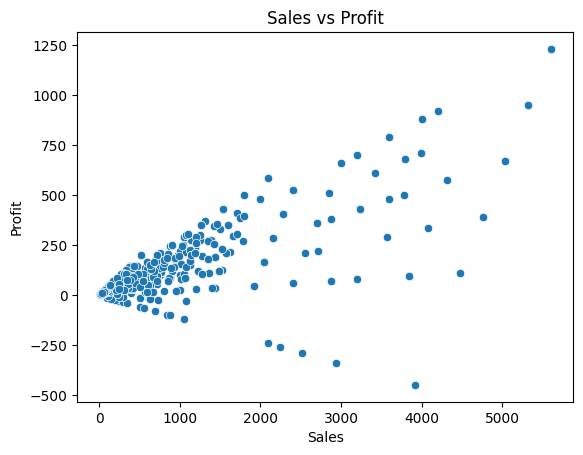

In [90]:
sns.scatterplot(x="Sales", y="Profit", data=df)
plt.title("Sales vs Profit")
plt.show()

## 21. Discount vs. Average Sales

We check whether discount levels show a consistent relationship with average sales.

**Insight:** Average sales fluctuate across discount levels rather than showing a consistent upward or downward pattern. In contrast, the earlier analysis showed a clear association between higher discounts and lower average profit.

In [91]:
df.groupby("Discount")["Sales"].mean().round(2)

,Sales
Discount,
0.00,664.30
0.05,529.60
0.10,597.35
0.15,557.56
0.20,579.84
0.30,609.90


## 22. Investigating Loss-Making Orders

We inspect the loss-making orders in detail to identify common characteristics.

**Insight:** All observed loss-making orders occur at the **30% discount level** and are concentrated mainly in Electronics and Furniture. In each case, cost exceeds sales, producing a negative profit.

This is an observed association in this dataset; it does not prove that discount alone causes the losses.

In [92]:
df[df["Profit"] < 0][["Category", "Sales", "Cost", "Discount", "Profit"]].sort_values("Profit")

,Category,Sales,Cost,Discount,Profit
108,Electronics,3920.0,4368.0,0.3,-448.0
629,Electronics,2940.0,3276.0,0.3,-336.0
958,Electronics,2940.0,3276.0,0.3,-336.0
111,Electronics,2520.0,2808.0,0.3,-288.0
1078,Electronics,2240.0,2496.0,0.3,-256.0
613,Electronics,2100.0,2340.0,0.3,-240.0
754,Electronics,1050.0,1170.0,0.3,-120.0
152,Electronics,875.0,975.0,0.3,-100.0
77,Electronics,840.0,936.0,0.3,-96.0
926,Electronics,700.0,780.0,0.3,-80.0


# 23. Data Cleaning

After exploring the raw dataset, we now address the identified data-quality issues.

The raw data contains missing values and duplicate records. We clean these issues only after understanding the underlying data.

In [93]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Ship_Date,0
Customer,12
Region,10
Category,0
Product,0
Quantity,0
Unit_Price,0
Discount,7


### Removing Duplicate Records

We remove the exact duplicate rows identified during the initial inspection.

In [94]:
df.drop_duplicates(inplace=True)


### Verify Duplicate Removal

The duplicate count should now be zero.

In [95]:
df.duplicated().sum()

np.int64(0)

### Handling Missing Categorical Values

For categorical columns, missing values are replaced with the mode—the most frequently occurring value.

This is a simple imputation strategy used here for practice; in a real project, the choice should also consider business context and the missingness mechanism.

In [96]:
for col in ["Customer", "Region", "Shipping_Mode"]:
    df[col] = df[col].fillna(df[col].mode()[0])

### Handling Missing Discount Values

Discount is numerical, so missing values are replaced with the median. The median is less sensitive to extreme values than the mean.

In [97]:
df["Discount"] = df["Discount"].fillna(df["Discount"].median())

### Verify Missing Values

We confirm that no missing values remain after cleaning.

In [98]:
df.isna().sum()

,0
Order_ID,0
Order_Date,0
Ship_Date,0
Customer,0
Region,0
Category,0
Product,0
Quantity,0
Unit_Price,0
Discount,0


# 24. Post-Cleaning Dataset

We check the final dataset dimensions after removing duplicates.

In [99]:
df.shape

(1200, 14)

## 25. Rechecking Category Profit After Cleaning

We repeat an important analysis after cleaning to confirm that the main conclusion is stable.

**Insight:** Electronics still has the highest average profit after cleaning, although its average changes slightly from the raw-data analysis.

In [100]:
df.groupby('Category')['Profit'].mean().round(2)

,Profit
Category,
Accessories,42.07
Electronics,177.11
Furniture,136.46
Office Supplies,19.54


## 26. Rechecking Discount vs. Profit After Cleaning

We repeat the discount-profit analysis on the cleaned dataset.

**Final Insight:** Average profit decreases consistently as the discount level increases. At a 30% discount, average profit becomes negative (**-$51.82**), while the average profit at 0% discount is **$163.65**.

In [101]:
df.groupby('Discount')['Profit'].mean().round(2)

,Profit
Discount,
0.00,163.65
0.05,111.77
0.10,99.45
0.15,62.73
0.20,28.87
0.30,-51.82


# 27. Final Findings & Conclusion

## Key Findings

1. **Electronics** has the highest average profit after cleaning (**$177.11**), but also the highest profit variability.
2. **Furniture** has the highest median profit, showing that mean and median can provide different views of category performance.
3. **Office Supplies** has the highest profit margin (**36.54%**), despite having the lowest average profit.
4. **North** has the highest total sales, highest average sales per order, and highest average profit among the regions.
5. **Sales and Profit** have a strong positive correlation (**0.81**).
6. **Higher discounts are associated with lower average profit**. At 30% discount, average profit is negative (**-$51.82**).
7. All observed loss-making orders occurred at the **30% discount level**, mainly in Electronics and Furniture.
8. Monthly sales fluctuate substantially, with **June 2024** recording the highest monthly sales and no consistent long-term upward or downward trend.

## Conclusion

This analysis demonstrates the importance of looking beyond a single metric. Average profit, median profit, variability, and profit margin can tell different stories about the same category.

The strongest profitability pattern in this dataset is the relationship between discounting and profit: higher discount levels are associated with progressively lower average profit, with the 30% discount level producing negative average profit.

The cleaned dataset was then rechecked to ensure that the major conclusions remained consistent after data-quality issues were addressed.
